## Import Libraries

In [158]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.mixture import GaussianMixture
from scipy.stats import norm

## Load Data

In [159]:
mode1 = pd.read_excel("data/mode1.xlsx")
mode2 = pd.read_excel("data/mode2.xlsx")

In [160]:
mode1.head()

,X
0,95.795
1,235.536
2,125.419
3,194.497
4,124.638


In [161]:
mode2.head()

,X1,X2
0,107.705,95.795
1,85.020,235.536
2,154.556,125.419
3,119.904,194.497
4,131.874,124.638


## Gaussian Mixture Model Configuration Code

In [162]:
# Best GMM Congifuration Code

def determine_best_gmm_config(data, min_components, max_components):
    '''
        This function estimates the gmm parameters with the EM algorithm
        for varying cluster sizes. The BIC and AIC is then determined for
        each model and stored in a dataframe

        Args:
            data: The input data to be clustered
            min_components: Minimum number of components for the cluster range
            max_components: Maximum number of components for the cluster range
        Returns:
            A tuple containing:
            - models (list): List of all the models
            - gmm_results: DataFrame with cluster count, BIC score and AIC score

    '''
    
    models = []

    # Best model is based on the model that minimizes a theorectical information criterion
    bic_scores = []     # Bayesian Information Criterion
    aic_scores = []     # Akaike Information Criterion

    cluster_range = range(min_components, max_components + 1)

    # Iterate through different component (cluster) amounts
    for cluster_nr in cluster_range:
        gmm = GaussianMixture(n_components=cluster_nr, n_init=10, random_state=42)

        gmm.fit(data)

        models.append(gmm)
        bic_scores.append(gmm.bic(data))
        aic_scores.append(gmm.aic(data))

    gmm_results = pd.DataFrame({
        "Clusters": list(cluster_range),
        "BIC_Score": bic_scores,
        "AIC_Score": aic_scores
    })

    print(gmm_results)

    return models, gmm_results

In [163]:
def plot_results(gmm_results):
    '''
        This function plots the BIC and AIC results obtained from running
        the determine_best_gmm_config function

        Args:
            gmm_results: Output from determine_best_gmm_config function
    '''

    # Plot results
    plt.figure(figsize=(8, 5))
    plt.plot(gmm_results["Clusters"], gmm_results["BIC_Score"], marker="o", label="BIC")
    plt.plot(gmm_results["Clusters"], gmm_results["AIC_Score"], marker="o", label="AIC")
    plt.xlabel("Number of clusters")
    plt.ylabel("Score")
    plt.title("AIC and BIC for Gaussian Mixture Models")
    plt.legend()
    plt.show()

    return 

def get_best_model(models, gmm_results):
    '''
        This function returns the model based on best BIC and AIC scores.
        If they differ, BIC is preferred.

        Args:
            models: List of all the models
            gmm_results: Output from determine_best_gmm_config function
        Returns:
            A tuple containing:
            - best_cluster_count (int): The optimal number of clusters.
            - best_model (GaussianMixture): The fitted GMM object.
    '''

    # Best model has the lowest BIC and AIC
    # If they differ, BIC is preferred since it penalises overly complex models more strongly
    best_cluster_count = gmm_results.loc[gmm_results['BIC_Score'].idxmin(), 'Clusters']

    best_model = models[best_cluster_count-1]

    print("Best number of clusters according to BIC:", best_cluster_count)

    return best_cluster_count, best_model

## Analysis: Mode1

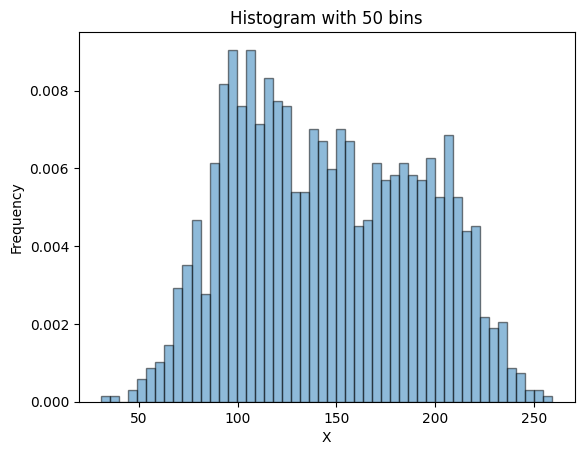

In [164]:
# Create histogram
bins = 50

plt.hist(mode1, bins=bins, density=True, edgecolor="black", alpha=0.5)
plt.title(f"Histogram with {bins} bins")
plt.xlabel("X")
plt.ylabel("Frequency")
plt.show()

Based on histogram, looks like there is 4 clusters. Let's loop from 1 to 8 clusters.

In [165]:
mode1_models, mode1_gmm_results = determine_best_gmm_config(mode1, 1, 8)

   Clusters     BIC_Score     AIC_Score
0         1  15775.031856  15764.405415
1         2  15610.668807  15584.102705
2         3  15611.827957  15569.322194
3         4  15639.482451  15581.037027
4         5  15656.048602  15581.663517
5         6  15679.415567  15589.090820
6         7  15698.198567  15591.934159
7         8  15719.192054  15596.987985


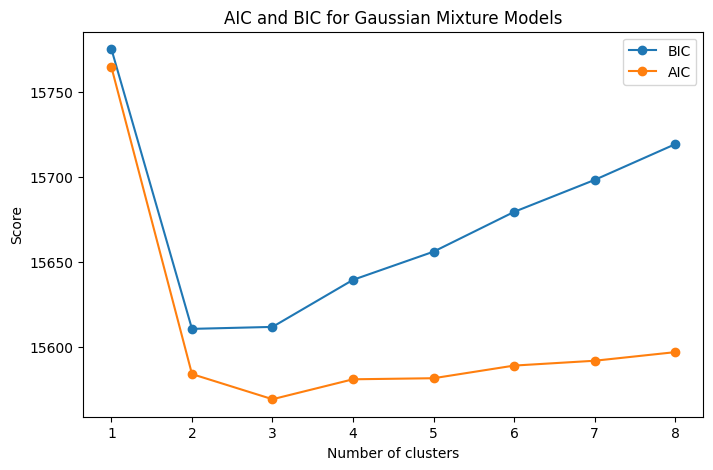

In [166]:
plot_results(mode1_gmm_results)

In [167]:
mode1_best_cluster_count, model1_best_model = get_best_model(mode1_models, mode1_gmm_results)

# Even though k = 2 has lowest BIC score, k = 2 and k = 3 are very close but k = 3 has 
# a much lower AIC score, therefore select k = 3
mode1_best_cluster_count = 3
model1_best_model = mode1_models[mode1_best_cluster_count-1]
print("Best number of clusters overall:", mode1_best_cluster_count)

Best number of clusters according to BIC: 2
Best number of clusters overall: 3


/Users/vishalbhaga/Documents/University/Year 1/MIT801/Assignments/SL/MIT801_HW1.2_SL/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(
/Users/vishalbhaga/Documents/University/Year 1/MIT801/Assignments/SL/MIT801_HW1.2_SL/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


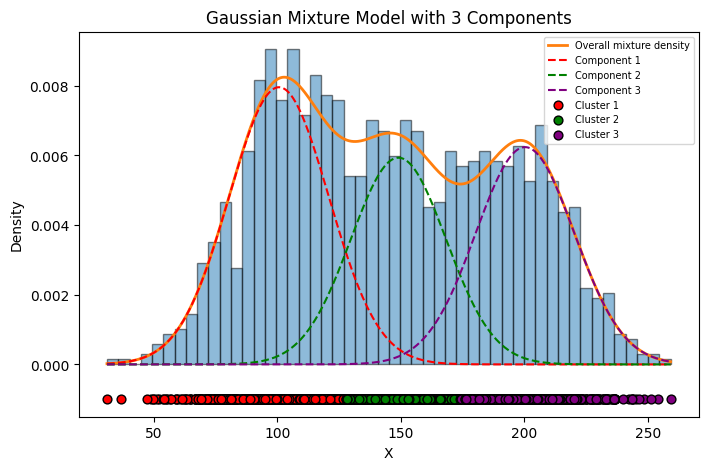

In [168]:
# Plot histogram overlayed with PDF of the overall model and the individual Gaussian components

# Make sure mode1 is shaped correctly for sklearn
X = np.asarray(mode1).reshape(-1, 1)

# Classify Data
cluster_labels = model1_best_model.predict(X)

# Get component means
means = model1_best_model.means_.flatten()

# Sort components from left to right
order = np.argsort(means)

# Map old sklearn labels to new ordered labels
label_map = {old_label: new_label for new_label, old_label in enumerate(order)}

# Remapped labels: 0, 1, 2 from left to right
cluster_labels = np.array([label_map[label] for label in cluster_labels])

# Grid for plotting the fitted density
x_grid = np.linspace(X.min(), X.max(), 1000).reshape(-1, 1)

# Evaluate GMM density on the grid
log_probs = model1_best_model.score_samples(x_grid)
density = np.exp(log_probs)

# Get GMM parameters for indivudal Gaussian components
means = model1_best_model.means_.flatten()
stds = np.sqrt(model1_best_model.covariances_).flatten()
weights = model1_best_model.weights_

# One colour per component
colors = ['red','green','purple']

# Histogram of original data
plt.figure(figsize=(8, 5))
plt.hist(X.flatten(), bins=50, density=True, edgecolor="black", alpha=0.5)

# Density overlayed
plt.plot(x_grid, density, linewidth=2, label="Overall mixture density")

# Individual Gaussian components
for i, (mean, std, weight) in enumerate(zip(means, stds, weights)):
    component_density = weight * norm.pdf(x_grid.flatten(), mean, std)

    plt.plot(
        x_grid,
        component_density,
        linestyle="--",
        color=colors[i],
        label=f"Component {i+1}"
    )

# Plot clustered points using matching component colours
for i in range(model1_best_model.n_components):
    mask = cluster_labels == i

    plt.scatter(
        X.flatten()[mask],
        np.full(mask.sum(), -0.001),
        color=colors[i],
        edgecolor="black",
        s=40,
        label=f"Cluster {i+1}"
    )

plt.xlabel("X")
plt.ylabel("Density")
plt.title(f"Gaussian Mixture Model with {mode1_best_cluster_count} Components")
plt.legend(loc="upper right", fontsize=7)
plt.show()

In [169]:
mode1_clustered = pd.DataFrame({
    "X": X.flatten(),
    "Cluster": cluster_labels + 1   # +1 so clusters are labelled 1, 2, 3
})

mode1_summary = mode1_clustered.groupby("Cluster")["X"].agg(
    Count="count",
    Mean="mean",
    Std="std",
    Min="min",
    Max="max"
)

mode1_summary

,Count,Mean,Std,Min,Max
Cluster,,,,,
1,617,99.565818,18.042669,30.938,127.311
2,420,150.663121,13.204376,127.923,173.852
3,463,202.098177,17.521059,173.945,259.269


## Analysis: Mode2

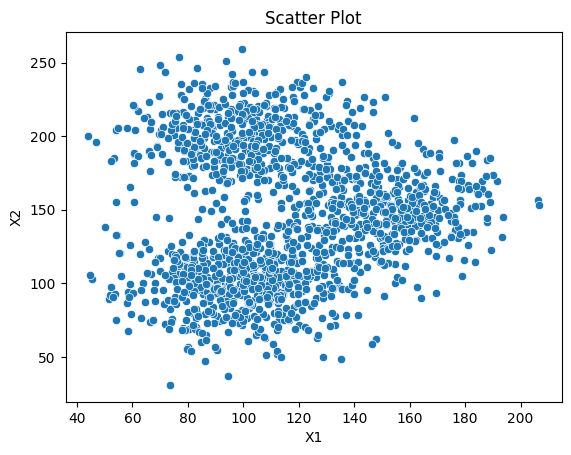

In [170]:
# 2D data is better visualised using a scatterplot
sns.scatterplot(data=mode2, x="X1", y="X2")

plt.title("Scatter Plot")
plt.show()

Based on the scatter plot, it looks like there is 3 clusters

In [171]:
mode2_models, mode2_gmm_results = determine_best_gmm_config(mode2, 1, 6)

   Clusters     BIC_Score     AIC_Score
0         1  30304.879149  30278.313047
1         2  29698.988452  29640.543028
2         3  29505.434714  29415.109968
3         4  29550.434499  29428.230431
4         5  29589.976898  29435.893507
5         6  29627.102246  29441.139533


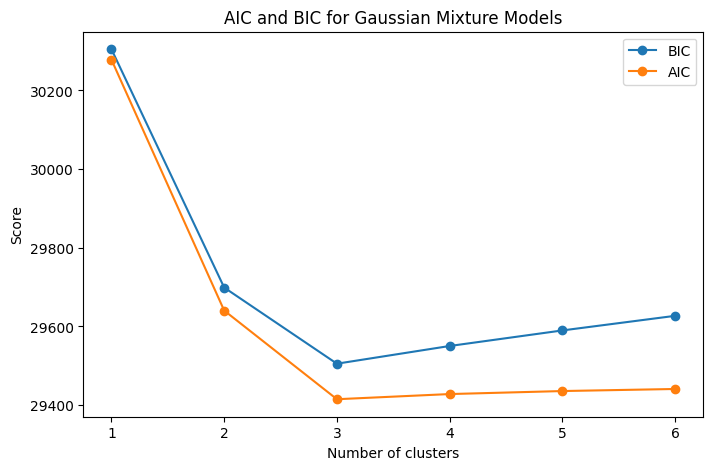

In [172]:
plot_results(mode2_gmm_results)

In [173]:
mode2_best_cluster_count, mode2_best_model = get_best_model(mode2_models, mode2_gmm_results)

Best number of clusters according to BIC: 3


/Users/vishalbhaga/Documents/University/Year 1/MIT801/Assignments/SL/MIT801_HW1.2_SL/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


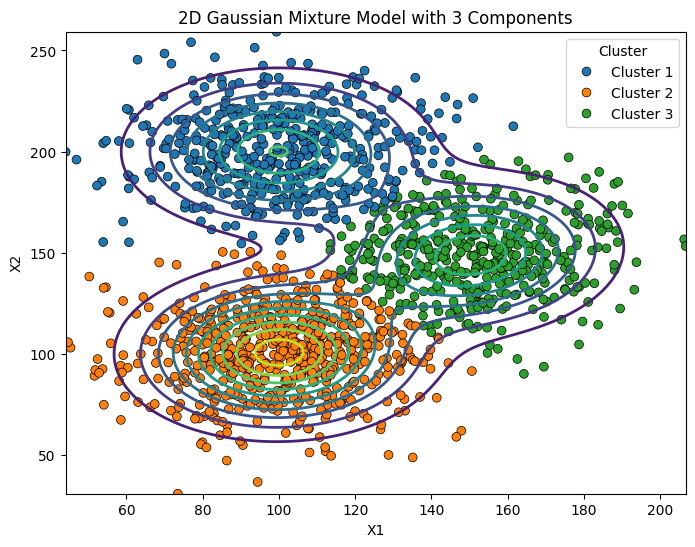

In [174]:
# Plot data in a 2D space with the PDF overlayed and points clustered

# Classify Data
cluster_labels = mode2_best_model.predict(mode2[["X1", "X2"]])

# Add custom cluster names
mode2["Cluster"] = [f"Cluster {label + 1}" for label in cluster_labels]

cluster_order = [f"Cluster {i + 1}" for i in sorted(np.unique(cluster_labels))]

# Scatter plot of the raw data
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=mode2,
    x="X1",
    y="X2",
    hue="Cluster",
    hue_order=cluster_order,
    palette="tab10",
    s=40,
    edgecolor="black"
)

# Create a 2D grid over the range of the data
x = np.linspace(mode2["X1"].min(), mode2["X1"].max(), 200)
y = np.linspace(mode2["X2"].min(), mode2["X2"].max(), 200)

X_grid, Y_grid = np.meshgrid(x, y)

# Combine grid coordinates into shape (number_of_points, 2)
grid_points = np.column_stack([X_grid.ravel(), Y_grid.ravel()])

# Evaluate GMM density on the grid
log_probs = mode2_best_model.score_samples(grid_points)
density = np.exp(log_probs)

# Reshape density back to grid shape
Z = density.reshape(X_grid.shape)

# Plot density contours
plt.contour(X_grid, Y_grid, Z, levels=10, linewidths=2)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title(f"2D Gaussian Mixture Model with {mode2_best_cluster_count} Components")
plt.show()

In [175]:
mode2_clustered = mode2.copy()
mode2_clustered["Cluster"] = cluster_labels + 1

mode2_summary = mode2_clustered.groupby("Cluster").agg(
    Count=("Cluster", "count"),
    X1_Mean=("X1", "mean"),
    X1_Std=("X1", "std"),
    X1_Min=("X1", "min"),
    X1_Max=("X1", "max"),
    X2_Mean=("X2", "mean"),
    X2_Std=("X2", "std"),
    X2_Min=("X2", "min"),
    X2_Max=("X2", "max")
)

mode2_summary.round(2)

,Count,X1_Mean,X1_Std,X1_Min,X1_Max,X2_Mean,X2_Std,X2_Min,X2_Max
Cluster,,,,,,,,,
1,465,99.64,19.90,44.04,161.49,200.53,19.63,154.59,259.27
2,603,99.61,19.27,44.65,150.63,100.46,19.85,30.94,150.51
3,432,152.11,18.14,113.49,206.71,149.21,19.18,90.18,197.15
